# Injector profile comparison: measured vs `lucid.sources.laser_source`

For each profile in `UKLIinfo/LightInjectors.json`, plot the measured (theta, phi) power
map next to what the current LUCiD laser/collimator model (`generate_laser_photons` /
`laser_source`) would produce with an opening half-angle set to roughly match.

The real profiles are: `OD collimator 10`, `OD collimator 13`, `ID diffuser`, and (as of the
fitting section below) `OD diffuser` -- its composite-fit parameters agree closely with `ID
diffuser`'s (cutoff angle ~45 deg in both, core width/shape close too), which is strong
evidence it's real measured data, not a placeholder. `ID collimator` and `laser ball` remain
placeholders (too few points / explicit todo).

**Convention note**: in this dataset theta=90 is boresight (confirmed -- all real profiles
peak at theta~88-90, phi~0). The collimators have a real phi scan: off-boresight angle is the
true 3D angle `alpha = arccos(sin(theta)*cos(phi))`, which for a narrow cone reduces to the
Euclidean radius `sqrt((theta-90)^2 + phi^2)` -- confirmed against the data, it's a circular
spot, not a band. The diffusers' scans never actually varied phi (checked directly: intensity
at theta=90 is flat to <0.2% across the full 0-360 phi range for ID diffuser -- it's tiled,
not measured), so their model comparison uses `alpha = |theta-90|` instead, phi-independent,
since that's the only axis the scan actually constrains. This is pure numpy/matplotlib -- no
JAX/GPU needed, so there's no subprocess launcher here.

In [26]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('UKLIinfo/LightInjectors.json') as f:
    PROFILES = json.load(f)['profiles']

for i, e in enumerate(PROFILES):
    print(i, e.get('comment'), '| n_points =', len(e['theta']))

0 ID collimator | n_points = 6
1 OD collimator 10 | n_points = 3660
2 OD collimator 13 | n_points = 3660
3 ID diffuser | n_points = 32761
4 OD diffuser | n_points = 32761
5 laser ball positioned in the centre of the detector | n_points = 3


In [27]:
N_WATER = 1.33


def to_grid(entry):
    """Reshape a flat (theta, phi, intensity) profile into a regular 2D grid, peak-normalized."""
    th = np.asarray(entry['theta']); ph = np.asarray(entry['phi']); inten = np.asarray(entry['intensity'], dtype=float)
    theta_vals = np.array(sorted(set(th)))
    phi_vals = np.array(sorted(set(ph)))
    grid = np.full((len(theta_vals), len(phi_vals)), np.nan)
    ti = np.searchsorted(theta_vals, th)
    pi = np.searchsorted(phi_vals, ph)
    grid[ti, pi] = inten
    grid = grid / np.nanmax(grid)
    return theta_vals, phi_vals, grid


def model_grid(theta_vals, phi_vals, theta_max_deg, phi_dependent=True):
    """What the current laser_source cone model predicts on the same (theta, phi) axes.

    Boresight is (theta=90, phi=0). If phi_dependent, off-boresight angle is the TRUE 3D
    angle alpha = arccos(sin(theta)*cos(phi)) -- for a narrow cone this reduces to the
    Euclidean radius sqrt((theta-90)^2 + phi^2), confirmed against the measured collimator
    data (a circular spot, not a band). Use this for devices with a real phi scan.

    If not phi_dependent, alpha = |theta - 90| broadcast uniformly across phi -- for devices
    whose scan never actually varied phi (e.g. the ID diffuser entry: phi is tiled, not
    measured), so the model comparison should only be held to the theta profile it can
    actually be checked against.

    Implied radiant intensity for the current sampler is cos(alpha) inside the cone, zero
    outside (see generate_laser_photons: sin(theta)*cos(theta) photon density in theta ->
    cos(theta) power per steradian once you divide out the sin(theta) solid-angle element).
    Peak-normalized to 1, same convention as to_grid().
    """
    if phi_dependent:
        th = np.deg2rad(theta_vals)[:, None]
        ph = np.deg2rad(phi_vals)[None, :]
        alpha = np.rad2deg(np.arccos(np.clip(np.sin(th) * np.cos(ph), -1, 1)))
    else:
        alpha = np.abs(theta_vals - 90.0)[:, None] * np.ones((1, len(phi_vals)))
    return np.where(alpha <= theta_max_deg, np.cos(np.deg2rad(alpha)), 0.0)


def plot_heatmap(ax, theta_vals, phi_vals, grid, title):
    im = ax.pcolormesh(theta_vals, phi_vals, grid.T, cmap='viridis', vmin=0, vmax=1, shading='auto')
    ax.set_xlabel('Theta (degrees)'); ax.set_ylabel('Phi (degrees)'); ax.set_title(title)
    return im


def na_equivalent(theta_max_deg):
    return N_WATER * np.sin(np.deg2rad(theta_max_deg))

## ID diffuser vs model at 40 deg half-angle

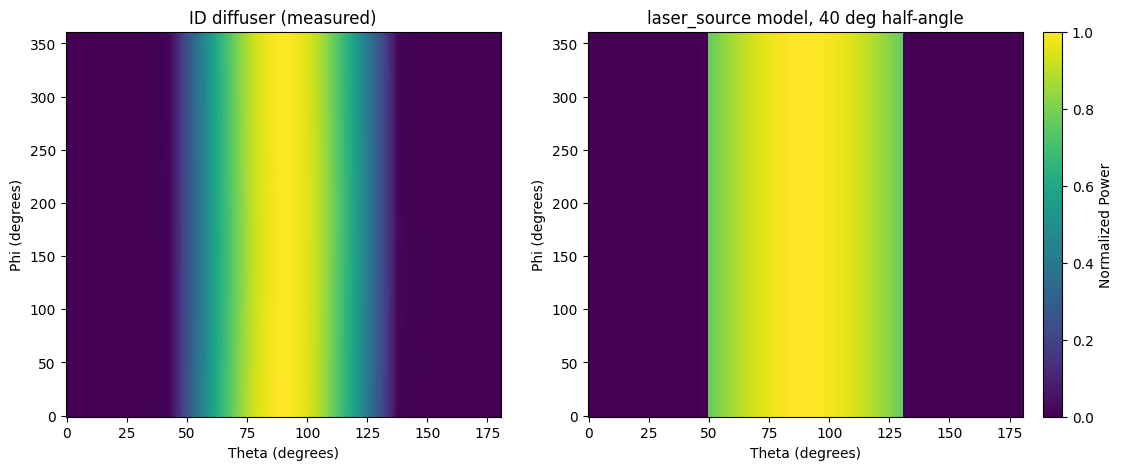

40 deg half-angle <-> fiber_NA = 0.855 in water (n=1.33)


In [28]:
entry = next(e for e in PROFILES if e['comment'] == 'ID diffuser')
theta_vals, phi_vals, real = to_grid(entry)
theta_max = 40.0
model = model_grid(theta_vals, phi_vals, theta_max, phi_dependent=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = plot_heatmap(axes[0], theta_vals, phi_vals, real, 'ID diffuser (measured)')
im1 = plot_heatmap(axes[1], theta_vals, phi_vals, model, f'laser_source model, {theta_max:.0f} deg half-angle')
fig.colorbar(im1, ax=axes, label='Normalized Power', fraction=0.03, pad=0.02)
plt.show()
print(f'{theta_max:.0f} deg half-angle <-> fiber_NA = {na_equivalent(theta_max):.3f} in water (n={N_WATER})')

## OD collimator 10 & 13 vs model at 2 deg and 4 deg half-angle

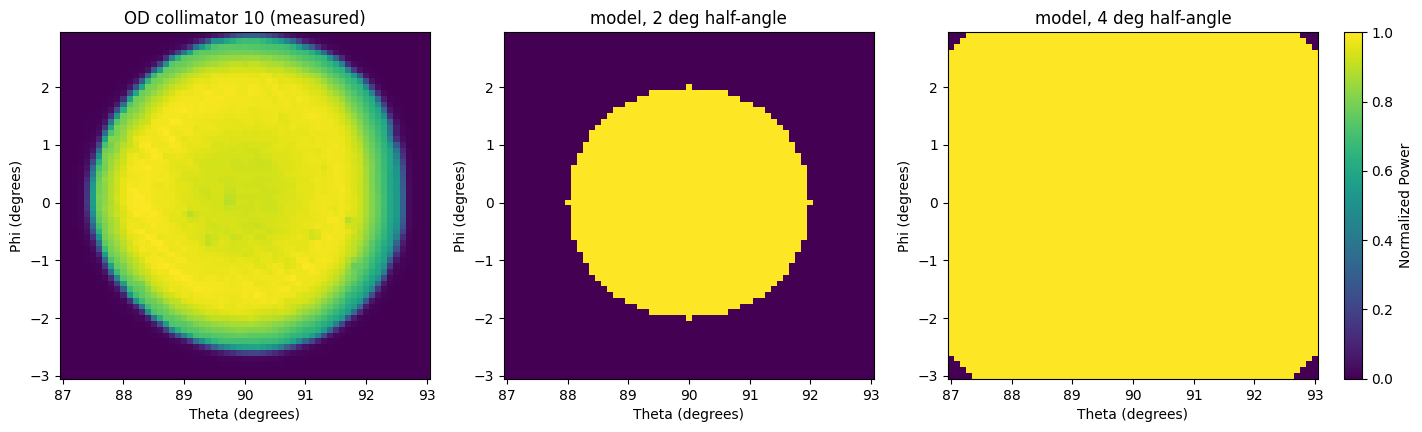

  OD collimator 10: 2 deg half-angle <-> fiber_NA = 0.0464
  OD collimator 10: 4 deg half-angle <-> fiber_NA = 0.0928


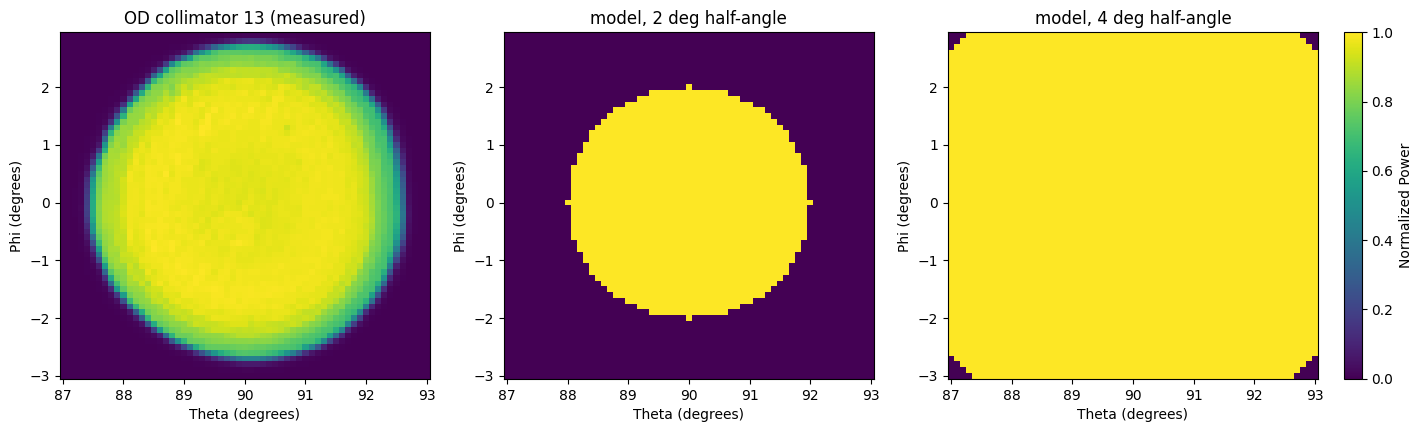

  OD collimator 13: 2 deg half-angle <-> fiber_NA = 0.0464
  OD collimator 13: 4 deg half-angle <-> fiber_NA = 0.0928


In [16]:
for name in ['OD collimator 10', 'OD collimator 13']:
    entry = next(e for e in PROFILES if e['comment'] == name)
    theta_vals, phi_vals, real = to_grid(entry)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    im0 = plot_heatmap(axes[0], theta_vals, phi_vals, real, f'{name} (measured)')
    for ax, theta_max in zip(axes[1:], [2.0, 4.0]):
        model = model_grid(theta_vals, phi_vals, theta_max)
        plot_heatmap(ax, theta_vals, phi_vals, model, f'model, {theta_max:.0f} deg half-angle')
    fig.colorbar(im0, ax=axes, label='Normalized Power', fraction=0.025, pad=0.02)
    plt.show()
    for theta_max in [2.0, 4.0]:
        print(f'  {name}: {theta_max:.0f} deg half-angle <-> fiber_NA = {na_equivalent(theta_max):.4f}')

## Fitting a common theta profile (uniform-in-phi assumption)

First approximation for both source types: uniform in phi, intensity varying only with the
off-boresight angle alpha (this is already the structural assumption `laser_source` makes --
its photon density is phi-uniform and only a function of theta). Under that assumption we can
collapse each measured profile to a 1D `intensity(alpha)` curve (true 3D `alpha` for the
collimators, `|theta-90|` for the diffusers per the phi-not-measured finding above) and fit a
parametric function to it.

Candidates:
- `cos(alpha)^n` -- the natural generalization of the CURRENT code's implicit shape
  (`generate_laser_photons` gives `cos(alpha)` = n=1 with a hard cutoff; this fits n instead
  of assuming it). Used for the collimators.
- Super-Gaussian `exp(-(alpha/w)^(2p))` -- smooth, `p>1` gives a flat top + soft edge, which a
  plain `cos^n` structurally cannot produce (peaked-at-center curves can't fake a plateau).
  Fits the collimators well (R2>0.996) but leaves systematic, non-random residuals on the
  diffusers (a shoulder around 27-41 deg, then a real cliff around 45-51 deg that a smooth
  tail can't reproduce).
- **Composite** `super_gauss(alpha; w, p) * fermi_edge(alpha; a0, s)` -- a diffuse Gaussian-
  like core times a soft(-ish) hard cutoff at `a0`, matching how the diffusers are actually
  built (a broad scattering core bounded by a real mechanical/geometric aperture edge). Used
  for the diffusers; the fitted edge softness `s` reports how hard that cutoff really is.

In [17]:
import ROOT
ROOT.gROOT.SetBatch(True)


def recenter_3d(theta_deg, phi_deg):
    """True 3D off-boresight angle for a device with a real phi scan (boresight at theta=90, phi=0)."""
    th = np.deg2rad(np.asarray(theta_deg)); ph = np.deg2rad(np.asarray(phi_deg))
    return np.degrees(np.arccos(np.clip(np.sin(th) * np.cos(ph), -1, 1)))


def bin_profile(alpha, inten, n_bins, amax=None):
    """Bin (alpha, intensity) into n_bins equal-width bins.

    Returns centers, per-bin mean, per-bin standard error of the mean (std/sqrt(count)),
    and per-bin count. The SEM is for display (error bars) only -- it's not a real
    measurement uncertainty (there isn't one), so it's not used to weight the fit below.
    """
    alpha = np.asarray(alpha); inten = np.asarray(inten, dtype=float)
    amax = alpha.max() if amax is None else amax
    bins = np.linspace(0, amax, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])
    count, _ = np.histogram(alpha, bins=bins)
    s, _ = np.histogram(alpha, bins=bins, weights=inten)
    s2, _ = np.histogram(alpha, bins=bins, weights=inten ** 2)
    with np.errstate(invalid='ignore'):
        mean = np.divide(s, count, out=np.full_like(s, np.nan, dtype=float), where=count > 0)
        var = np.divide(s2, count, out=np.full_like(s, np.nan, dtype=float), where=count > 0) - mean ** 2
        sem = np.sqrt(np.maximum(var, 0) / np.maximum(count, 1))
    floor = np.nanmax(mean) * 1e-3 if np.any(count > 0) else 1e-6
    sem = np.maximum(sem, floor)
    return centers, mean, sem, count


def cos_power(alpha_deg, n):
    a = np.deg2rad(np.clip(alpha_deg, 0, 89.999))
    return np.cos(a) ** n


def super_gauss(alpha_deg, w, p):
    return np.exp(-(np.asarray(alpha_deg) / max(w, 1e-6)) ** (2 * p))


def composite(alpha_deg, w, p, a0, s):
    """Diffuse Gaussian-like core (super_gauss) times a soft cutoff edge at a0 (Fermi-style).

    s is the edge softness in degrees: small s -> a genuinely hard mechanical cutoff,
    larger s -> a gradual falloff. Matches "diffuse core bounded by a real aperture edge."
    """
    core = super_gauss(alpha_deg, w, p)
    edge = 1.0 / (1.0 + np.exp((np.asarray(alpha_deg) - a0) / max(s, 1e-6)))
    return core * edge


_fit_counter = [0]


def least_squares_fit_minuit(x, y, yerr, model, param_names, init, limits=None):
    """Least-squares fit via ROOT's standard TF1 + TGraph::Fit() -> Minuit2 pathway.

    Unweighted (plain sum-of-squared-residuals): there's no real per-point measurement
    uncertainty here (yerr is binning spread, not a measurement error), so points are
    fit with equal weight via a plain TGraph rather than TGraphErrors. yerr is accepted
    but only used for the error-bar plot in the calling cell, not for fit weighting.
    Reported metric is RSS (residual sum of squares) only -- with unit weights ROOT's
    Chi2() is numerically the RSS, but it isn't a statistical chi2 (no real uncertainties
    behind it). RSS/ndf is not computed: without real errors it doesn't normalize to
    anything meaningful either, so it's dropped rather than reported as if it were.

    Goes through ROOT's normal C++ fit machinery (the same route essentially every
    PyROOT fitting tutorial uses) instead of driving ROOT.Math.Factory/Math.Functor by
    hand -- the latter's raw Python callback across the minimizer boundary is a known
    PyROOT crash point (segfaults reported across several ROOT/cppyy versions); TF1's
    callback convention is far more battle-tested.

    model(alpha, *params) -> array of predictions, same signature as cos_power/
    super_gauss/composite above.
    limits: list of (lo, hi) or None per parameter, for bounded fits.
    """
    x = np.asarray(x, dtype=float); y = np.asarray(y, dtype=float)
    npar = len(init)

    def wrapped(xarr, par):
        return float(model(xarr[0], *[par[i] for i in range(npar)]))

    _fit_counter[0] += 1
    fname = f'f1_{_fit_counter[0]}'
    f1 = ROOT.TF1(fname, wrapped, float(x.min()), float(x.max()), npar)

    for i, (pname, v0) in enumerate(zip(param_names, init)):
        f1.SetParName(i, pname)
        f1.SetParameter(i, float(v0))
        if limits is not None and limits[i] is not None:
            lo, hi = limits[i]
            f1.SetParLimits(i, float(lo), float(hi))

    graph = ROOT.TGraph(len(x), x, y)
    result = graph.Fit(f1, "S Q")

    values = [result.Parameter(i) for i in range(npar)]
    errors = [result.ParError(i) for i in range(npar)]
    rss = result.Chi2()  # unit weights -> Chi2() is numerically the residual sum of squares
    ndf = result.Ndf()
    return dict(names=param_names, values=values, errors=errors, rss=rss, ndf=ndf)

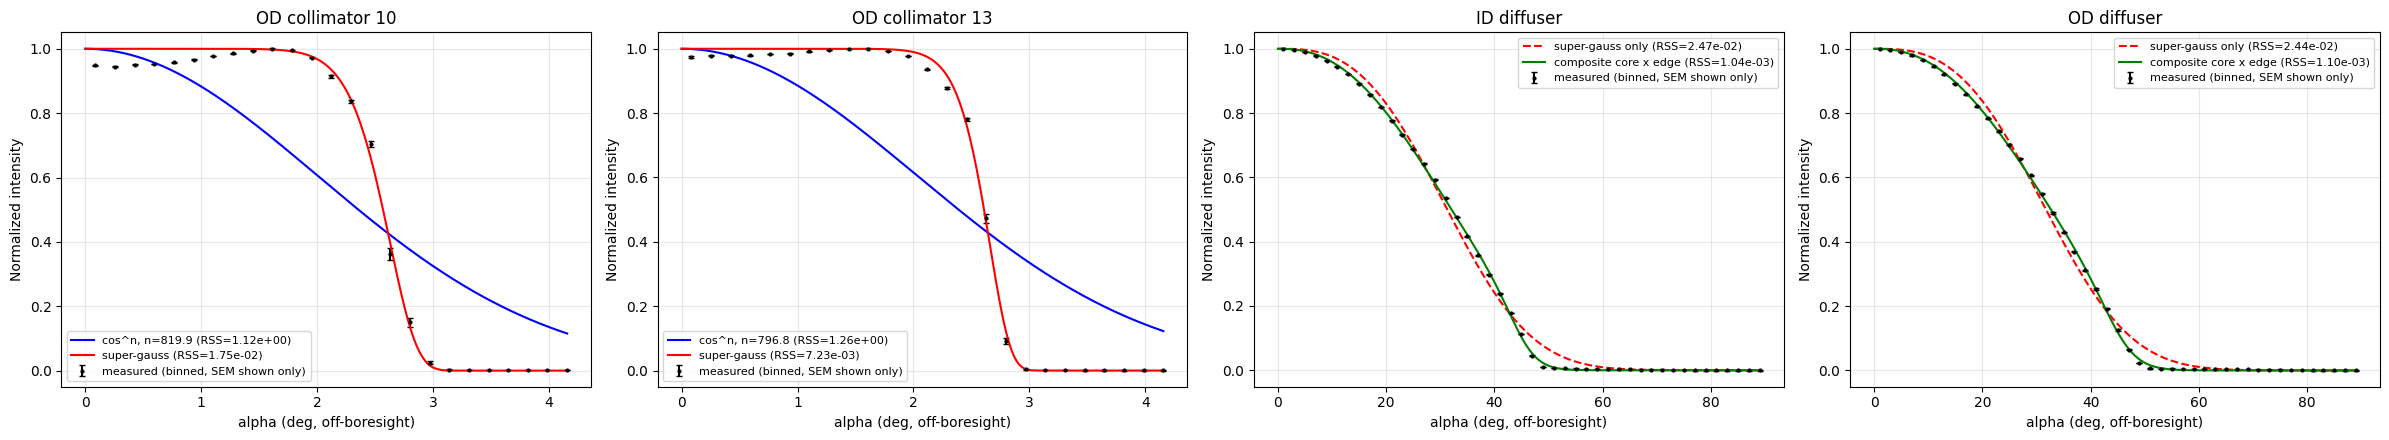

OD collimator 10:
  cos^n:       n=819.93+-114.41   RSS=1.1176e+00
  super-gauss: w=2.646+-0.011  p=6.107+-0.349   RSS=1.7539e-02
OD collimator 13:
  cos^n:       n=796.80+-117.57   RSS=1.2580e+00
  super-gauss: w=2.670+-0.006  p=7.935+-0.497   RSS=7.2340e-03
ID diffuser:
  super-gauss only: w=35.47+-0.24  p=1.46+-0.04   RSS=2.4676e-02
  composite:        w=37.48+-0.17  p=1.20+-0.03  a0=44.86+-0.28  s=2.40+-0.07   RSS=1.0354e-03
OD diffuser:
  super-gauss only: w=35.95+-0.24  p=1.47+-0.04   RSS=2.4381e-02
  composite:        w=38.54+-0.32  p=1.17+-0.03  a0=44.98+-0.29  s=2.89+-0.08   RSS=1.0977e-03


In [18]:
fit_specs = [
    ('OD collimator 10', recenter_3d, 25, None, 'collimator'),
    ('OD collimator 13', recenter_3d, 25, None, 'collimator'),
    ('ID diffuser', lambda th, ph: np.abs(np.asarray(th) - 90.0), 45, 90.0, 'diffuser'),
    ('OD diffuser', lambda th, ph: np.abs(np.asarray(th) - 90.0), 45, 90.0, 'diffuser'),
]

fig, axes = plt.subplots(1, len(fit_specs), figsize=(6 * len(fit_specs), 4.5))
fit_results = {}

for ax, (name, recenter_fn, n_bins, amax, kind) in zip(axes, fit_specs):
    entry = next(e for e in PROFILES if e['comment'] == name)
    alpha = recenter_fn(entry['theta'], entry['phi'])
    inten = np.asarray(entry['intensity'], dtype=float)
    centers, mean, sem, count = bin_profile(alpha, inten, n_bins, amax=amax)
    peak = np.nanmax(mean)
    mean = mean / peak; sem = sem / peak
    mask = ~np.isnan(mean)
    c, m, e_ = centers[mask], mean[mask], sem[mask]
    xx = np.linspace(0, c.max(), 300)
    ax.errorbar(c, m, yerr=e_, fmt='k.', ms=4, capsize=2, label='measured (binned, SEM shown only)')

    if kind == 'collimator':
        fit_cos = least_squares_fit_minuit(c, m, e_, cos_power, ['n'], init=[5.0], limits=[(0.01, 5000)])
        fit_sg = least_squares_fit_minuit(c, m, e_, super_gauss, ['w', 'p'], init=[c.max() / 2, 1.0],
                                           limits=[(0.01, 90), (0.1, 50)])
        fit_results[name] = dict(kind=kind, cos=fit_cos, sg=fit_sg)
        ax.plot(xx, cos_power(xx, *fit_cos['values']),
                'b-', label=f"cos^n, n={fit_cos['values'][0]:.1f} (RSS={fit_cos['rss']:.2e})")
        ax.plot(xx, super_gauss(xx, *fit_sg['values']),
                'r-', label=f"super-gauss (RSS={fit_sg['rss']:.2e})")
    else:
        fit_sg = least_squares_fit_minuit(c, m, e_, super_gauss, ['w', 'p'], init=[35.0, 1.5],
                                           limits=[(0.01, 90), (0.1, 50)])
        fit_comp = least_squares_fit_minuit(c, m, e_, composite, ['w', 'p', 'a0', 's'],
                                             init=[25.0, 1.0, 47.0, 2.0],
                                             limits=[(1, 90), (0.3, 10), (10, 89), (0.1, 20)])
        fit_results[name] = dict(kind=kind, sg=fit_sg, comp=fit_comp)
        ax.plot(xx, super_gauss(xx, *fit_sg['values']),
                'r--', label=f"super-gauss only (RSS={fit_sg['rss']:.2e})")
        ax.plot(xx, composite(xx, *fit_comp['values']),
                'g-', label=f"composite core x edge (RSS={fit_comp['rss']:.2e})")

    ax.set_xlabel('alpha (deg, off-boresight)'); ax.set_ylabel('Normalized intensity')
    ax.set_title(name); ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.tight_layout(); plt.show()

for name, r in fit_results.items():
    if r['kind'] == 'collimator':
        fc, fs = r['cos'], r['sg']
        print(f"{name}:")
        print(f"  cos^n:       n={fc['values'][0]:.2f}+-{fc['errors'][0]:.2f}   RSS={fc['rss']:.4e}")
        print(f"  super-gauss: w={fs['values'][0]:.3f}+-{fs['errors'][0]:.3f}  p={fs['values'][1]:.3f}+-{fs['errors'][1]:.3f}"
              f"   RSS={fs['rss']:.4e}")
    else:
        fs, fc = r['sg'], r['comp']
        print(f"{name}:")
        print(f"  super-gauss only: w={fs['values'][0]:.2f}+-{fs['errors'][0]:.2f}  p={fs['values'][1]:.2f}+-{fs['errors'][1]:.2f}"
              f"   RSS={fs['rss']:.4e}")
        print(f"  composite:        w={fc['values'][0]:.2f}+-{fc['errors'][0]:.2f}  p={fc['values'][1]:.2f}+-{fc['errors'][1]:.2f}"
              f"  a0={fc['values'][2]:.2f}+-{fc['errors'][2]:.2f}  s={fc['values'][3]:.2f}+-{fc['errors'][3]:.2f}"
              f"   RSS={fc['rss']:.4e}")

In [19]:
for e in PROFILES:
    if e['comment'] in ('ID diffuser', 'OD diffuser', 'OD collimator 10', 'OD collimator 13'):
        continue
    print(f"{e['comment']!r}: {len(e['theta'])} points", '-- todo: ' + e['todo'] if 'todo' in e else '-- placeholder')

'ID collimator': 6 points -- placeholder
'laser ball positioned in the centre of the detector': 3 points -- todo: generate theta, phi and z arrays using the csv file we have


## Diffuser and collimator as a common "blob" shape

Plotted in their own raw `(theta, phi)` axes, the diffuser looks like a band (theta ranges the
full 0-180 deg, phi is a full 0-360 deg roll) and the collimator looks like a disk (theta/phi
both span only a few degrees) -- different-looking, but that's a coordinate-system artifact,
not a difference in the underlying shape. Both are really a peaked profile radiating out from
a single boresight direction; they just need different transforms to reveal that:

- **Diffuser**: `phi` is a genuine full rotation (a roll angle), so `alpha=|theta-90|` (radius)
  and `phi` (azimuth) are already a true polar coordinate pair -- converting to Cartesian
  (`alpha*cos(phi), alpha*sin(phi)`) turns the band into a circular blob.
- **Collimator**: `phi` only spans a few degrees, not a full rotation, so treating it as an
  azimuth and applying the same polar conversion would just squash it flat. At this small a
  scale `(delta_theta, delta_phi)` is already an effectively flat tangent-plane `(x,y)` (the
  curvature that matters for the diffuser's large angles is negligible over a few degrees), so
  no transform is needed -- the raw axes already show the blob directly.

Same underlying shape, reached by the transform appropriate to how big a swing each device's
`phi` axis actually represents.

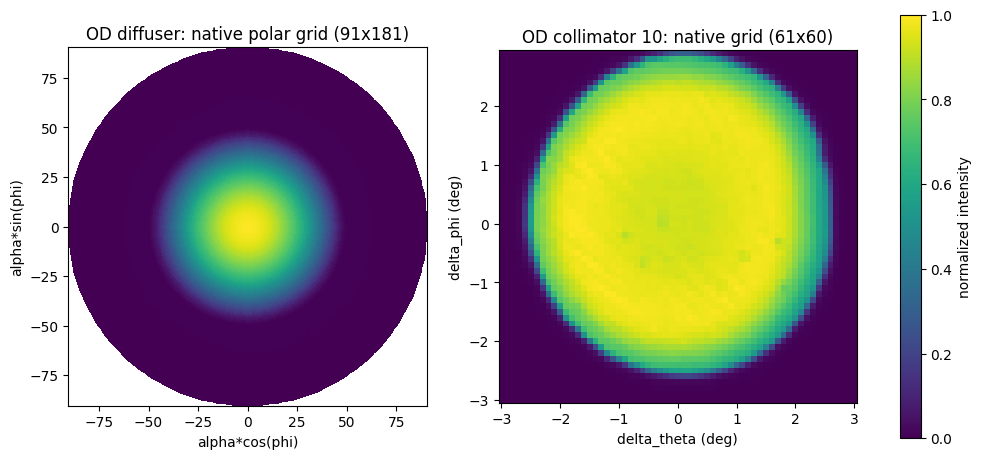

In [20]:
def edges_from_centers(vals):
    dv = np.diff(vals)
    return np.concatenate([[vals[0] - dv[0] / 2], vals[:-1] + dv / 2, [vals[-1] + dv[-1] / 2]])


def native_grid(theta_deg, phi_deg, intensity, theta0_deg, fold):
    """Native-resolution (axis1, axis2, intensity) grid, averaging any bin that gets
    hit more than once (fold=True: theta0+d/theta0-d collapse onto the same alpha bin
    for the diffuser) rather than overwriting -- np.add.at accumulates all hits per bin,
    divided by the per-bin count.
    """
    theta_deg = np.asarray(theta_deg, dtype=float); phi_deg = np.asarray(phi_deg, dtype=float)
    intensity = np.asarray(intensity, dtype=float)
    axis1 = np.round(np.abs(theta_deg - theta0_deg) if fold else theta_deg - theta0_deg, 6)
    axis2 = np.round(phi_deg, 6)
    axis1_vals = np.array(sorted(set(axis1))); axis2_vals = np.array(sorted(set(axis2)))
    sums = np.zeros((axis2_vals.size, axis1_vals.size)); counts = np.zeros_like(sums)
    i1 = np.searchsorted(axis1_vals, axis1); i2 = np.searchsorted(axis2_vals, axis2)
    np.add.at(sums, (i2, i1), intensity)
    np.add.at(counts, (i2, i1), 1)
    grid = np.divide(sums, counts, out=np.zeros_like(sums), where=counts > 0)
    return axis1_vals, axis2_vals, grid


fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

# diffuser: alpha=|theta-90| (folded, averaging the theta0+d/theta0-d duplicate) as radius,
# phi (roll) as azimuth -> native-resolution polar mesh, no rebinning/fidelity loss.
entry = next(e for e in PROFILES if e['comment'] == 'OD diffuser')
alpha_vals, roll_vals, grid = native_grid(entry['theta'], entry['phi'], entry['intensity'],
                                           theta0_deg=90.0, fold=True)
grid = grid / grid.max()
A, R = np.meshgrid(edges_from_centers(alpha_vals), np.radians(edges_from_centers(roll_vals)))
im0 = axes[0].pcolormesh(A * np.cos(R), A * np.sin(R), grid, cmap='viridis', vmin=0, vmax=1)
axes[0].set_aspect('equal')
axes[0].set_xlabel('alpha*cos(phi)'); axes[0].set_ylabel('alpha*sin(phi)')
axes[0].set_title(f'OD diffuser: native polar grid ({alpha_vals.size}x{roll_vals.size})')

# collimator: delta_theta/delta_phi native grid directly -- no fold, no duplicates, already
# effectively Cartesian at this small scale, so no polar conversion needed either.
entry = next(e for e in PROFILES if e['comment'] == 'OD collimator 10')
dtheta_vals, dphi_vals, grid_c = native_grid(entry['theta'], entry['phi'], entry['intensity'],
                                              theta0_deg=90.0, fold=False)
grid_c = grid_c / grid_c.max()
im1 = axes[1].pcolormesh(edges_from_centers(dtheta_vals), edges_from_centers(dphi_vals),
                          grid_c, cmap='viridis', vmin=0, vmax=1)
axes[1].set_aspect('equal')
axes[1].set_xlabel('delta_theta (deg)'); axes[1].set_ylabel('delta_phi (deg)')
axes[1].set_title(f'OD collimator 10: native grid ({dtheta_vals.size}x{dphi_vals.size})')

fig.colorbar(im1, ax=axes, fraction=0.025, label='normalized intensity')
plt.show()

## Sampling any common-format profile with the correct solid-angle weight

`common_profiles/*.npz` stores raw, unmodified `goalTheta`/`goalPhi` (see
`build_common_profiles.ipynb`). `theta_raw` is a genuine spherical colatitude for both device
types (the collimator's real 2-axis raster around a stationary device; the diffuser's real
theta sweep, even though its `phi`/roll is the device's own rotation about its boresight, not
a second real spatial axis) -- so `dOmega = sin(theta_raw) dtheta_raw dphi` is the textbook
solid-angle element, the same formula for both.

**Sampling method: inverse-CDF sampling in `(cosTheta, phi)`, not `(theta, phi)`.**
Proposing/weighting in raw `theta` and correcting for `sin(theta_raw)` with a Jacobian
*after* the fact (an earlier version of this) is fragile exactly where the Jacobian is
small -- which for the diffuser is right at its peak, the worst possible place. Since
`dOmega = -d(cosTheta) dphi`, relabeling the theta axis as `u=cos(theta_raw)` (a pure,
order-reversing relabel of the existing grid, not a rebinning) makes `(u, phi)` a genuinely
*flat* measure -- building the CDF and drawing from it needs no Jacobian anywhere, since
there's nothing left to weight. This is the same trick WCSim's own `MonotonicInterpolator`
relies on -- its grid is built directly on `cosTheta` (`WCSimLIGen::LoadProfilePDF`), not
`theta`. An intermediate version of this sampled via batched rejection instead of a CDF (still
correct, since it also worked in cosTheta, just more expensive); `build_2d_cdf_u` +
`sample_common_profile` now invert the CDF directly, so every uniform draw maps to exactly one
sample with no oversampling/retry loop. `load_raw_grid` reads the raw, unfolded native grid
directly, with no alpha-folding needed at all for the sampler (folding is still needed,
separately, by the phi-independent radial fit further down, which does want a folded,
recentered alpha).

The dense mesh the CDF is built from uses `bilinear_lookup` rather than a PCHIP row-then-column
fit -- simpler, and sidesteps the separate 2D-interpolation-separability question PCHIP raised
(whether upsampling introduces artifacts near a non-axis-aligned edge), which was always an
issue independent of the Jacobian one.

/tmp/ipykernel_598689/16187076.py:122: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  marginal = np.trapz(dense, fine_phi, axis=0)  # no jacobian -- u is already flat


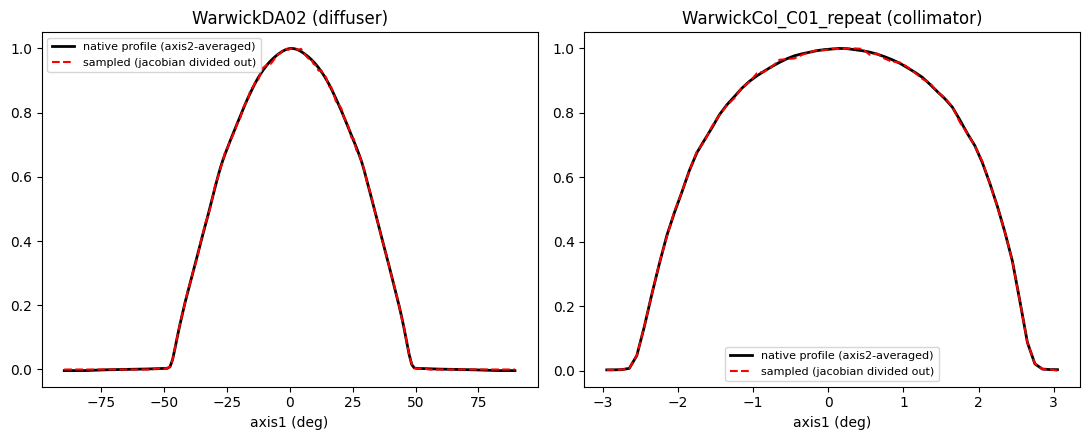

diffuser: max |ratio-1| over well-populated bins = 1.000
collimator: max |ratio-1| over well-populated bins = 1.000


In [21]:
from pathlib import Path

COMMON_DIR = Path('common_profiles')


def dedupe_wraparound_phi(phi_vals, grid):
    """goalPhi for the diffuser runs 0..360 inclusive -- 0 and 360 are the same physical
    angle recorded as two separate rows. Average them into one exact-duplicate merge."""
    phi_mod = np.round(phi_vals % 360.0, 6)
    uniq = np.array(sorted(set(phi_mod)))
    if uniq.size == phi_vals.size:
        return phi_vals, grid
    idx = np.searchsorted(uniq, phi_mod)
    sums = np.zeros((uniq.size, grid.shape[1])); counts = np.zeros((uniq.size, 1))
    np.add.at(sums, idx, grid)
    np.add.at(counts, idx, 1)
    return uniq, sums / counts


def fold_theta(theta_vals, phi_vals, grid, theta0=90.0):
    """Fold raw theta around theta0 into alpha=|theta-theta0|, averaging only genuinely
    duplicate measurements of the same true device-frame direction -- used by the
    phi-independent radial fit below (fit_common_profile), which needs a folded alpha.
    Not used by the sampler (see markdown above): it works directly off the raw, unfolded
    grid instead.

    theta0+d at roll=r and theta0-d at roll=r are NOT duplicates -- a 180 deg rotation
    about the boresight relates theta0+d to theta0-d, so at the SAME roll they sample
    device-azimuths 180 deg apart (averaging them, an earlier bug, silently erases any
    real asymmetry). The genuine duplicate of (theta0+d, roll=r) is (theta0-d,
    roll=(r+180) mod 360) -- exact, not approximate, since the roll axis is a regular
    0-360 sweep (once the 0/360 wraparound duplicate is merged) and 180 deg is itself a
    multiple of its step, so this is a permutation of the existing roll grid, not rebinning.
    Returns (alpha_vals, phi_vals, grid) -- phi_vals is the deduped axis2 to use downstream.
    """
    phi_vals, grid = dedupe_wraparound_phi(phi_vals, grid)
    delta = np.round(theta_vals - theta0, 6)
    phi_vals = np.round(phi_vals, 6)
    pos, neg, zero = delta > 0, delta < 0, delta == 0

    alpha_pos = delta[pos]
    alpha_neg = -delta[neg]
    assert np.array_equal(np.sort(alpha_pos), np.sort(alpha_neg)), \
        'raw theta grid must be symmetric about theta0 for this pairing to be exact'
    order_pos, order_neg = np.argsort(alpha_pos), np.argsort(alpha_neg)
    alpha_vals = alpha_pos[order_pos]

    grid_pos, grid_neg = grid[:, pos][:, order_pos], grid[:, neg][:, order_neg]
    phi_pos_target = np.round((-phi_vals) % 360.0, 6)          # theta0+d's true device azimuth
    phi_neg_target = np.round((180.0 - phi_vals) % 360.0, 6)   # theta0-d's true device azimuth
    row_pos = np.searchsorted(phi_vals, phi_pos_target)
    row_neg = np.searchsorted(phi_vals, phi_neg_target)
    assert set(row_pos) == set(row_neg) == set(range(phi_vals.size)), \
        'phi grid must be a regular 0-360 sweep for the +180 deg pairing to land exactly'

    out_pos = np.empty_like(grid_pos); out_pos[row_pos] = grid_pos
    out_neg = np.empty_like(grid_neg); out_neg[row_neg] = grid_neg
    out = 0.5 * (out_pos + out_neg)

    if zero.any():
        alpha_vals = np.concatenate([[0.0], alpha_vals])
        out = np.concatenate([grid[:, zero][:, :1], out], axis=1)
    return alpha_vals, phi_vals, out


def load_common_profile(sample_id):
    """Load raw (goalTheta, goalPhi, intensity) from common_profiles/<sample_id>.npz and
    reduce to the folded convention fit_common_profile needs: collimator keeps signed
    delta_theta (real 2D raster, no collision); diffuser folds to alpha=|delta_theta|."""
    d = np.load(COMMON_DIR / f'{sample_id}.npz', allow_pickle=True)
    theta_vals, phi_vals, grid, device_type = d['axis1_vals'], d['axis2_vals'], d['grid'], str(d['device_type'])
    if device_type == 'diffuser':
        axis1_vals, phi_vals, grid = fold_theta(theta_vals, phi_vals, grid, theta0=90.0)
    else:
        axis1_vals = theta_vals - 90.0
    return axis1_vals, phi_vals, grid, device_type


def load_raw_grid(sample_id):
    """Load the native (theta_raw, phi_raw, intensity) grid for the sampler, unmodified
    except merging the phi=0/360 exact-duplicate wraparound reading -- no folding, no
    theta0 offset, so nothing is averaged away for either device type."""
    d = np.load(COMMON_DIR / f'{sample_id}.npz', allow_pickle=True)
    theta_vals, phi_vals, grid, device_type = d['axis1_vals'], d['axis2_vals'], d['grid'], str(d['device_type'])
    phi_vals, grid = dedupe_wraparound_phi(phi_vals, grid)
    return theta_vals, phi_vals, grid, device_type


def bilinear_lookup(axis1_vals, axis2_vals, grid, x, y):
    """Vectorized bilinear interpolation of grid (rows=axis2, cols=axis1) at query points
    (x, y) -- a weighted average of the four surrounding native values, so it can never
    overshoot outside their range. Naturally pointwise, and safe to call on a fine mesh
    too (no persistent 2D-separability surprises the way a row-then-column PCHIP fit had)."""
    x = np.clip(x, axis1_vals[0], axis1_vals[-1])
    y = np.clip(y, axis2_vals[0], axis2_vals[-1])
    i1 = np.clip(np.searchsorted(axis1_vals, x, side='right') - 1, 0, axis1_vals.size - 2)
    i2 = np.clip(np.searchsorted(axis2_vals, y, side='right') - 1, 0, axis2_vals.size - 2)
    x0, x1 = axis1_vals[i1], axis1_vals[i1 + 1]
    y0, y1 = axis2_vals[i2], axis2_vals[i2 + 1]
    tx = (x - x0) / (x1 - x0)
    ty = (y - y0) / (y1 - y0)
    g00, g10 = grid[i2, i1], grid[i2, i1 + 1]
    g01, g11 = grid[i2 + 1, i1], grid[i2 + 1, i1 + 1]
    top = g00 * (1 - tx) + g10 * tx
    bot = g01 * (1 - tx) + g11 * tx
    return top * (1 - ty) + bot * ty


def build_2d_cdf_u(u_vals, phi_vals, grid_u, n_fine_u=400, n_fine_phi=200):
    """Marginal + conditional CDF built directly in (u=cosTheta, phi) -- since u is
    already the flat solid-angle measure, there's no Jacobian anywhere in this
    construction (unlike the old theta-space CDF, whose correctness was an endless,
    error-prone argument). Dense mesh via bilinear_lookup rather than a PCHIP row-then-
    column fit -- simpler, and avoids the separate 2D-interpolation-separability question
    PCHIP raised, independent of the Jacobian issue.
    """
    fine_u = np.linspace(u_vals.min(), u_vals.max(), n_fine_u)
    fine_phi = np.linspace(phi_vals.min(), phi_vals.max(), n_fine_phi)
    UU, PP = np.meshgrid(fine_u, fine_phi)
    dense = bilinear_lookup(u_vals, phi_vals, grid_u, UU.ravel(), PP.ravel()).reshape(UU.shape)

    marginal = np.trapz(dense, fine_phi, axis=0)  # no jacobian -- u is already flat
    marginal_cdf = np.concatenate([[0.0], np.cumsum(0.5 * (marginal[1:] + marginal[:-1]) * np.diff(fine_u))])
    marginal_cdf = marginal_cdf / marginal_cdf[-1]

    cum = np.cumsum(0.5 * (dense[1:, :] + dense[:-1, :]) * np.diff(fine_phi)[:, None], axis=0)
    cond = np.concatenate([np.zeros((1, n_fine_u)), cum], axis=0)
    col_tot = cond[-1, :]; col_tot_safe = np.where(col_tot > 0, col_tot, 1.0)
    cond = cond / col_tot_safe[None, :]
    flat_fallback = np.linspace(0.0, 1.0, n_fine_phi)[:, None]
    cond = np.where(col_tot[None, :] > 0, cond, flat_fallback)
    return fine_u, marginal_cdf, fine_phi, cond.T  # (n_fine_u, n_fine_phi)


def sample_common_profile(sample_id, n=2_000_000, seed=0):
    """Inverse-CDF sampling directly in (cosTheta, phi) -- the flat solid-angle measure,
    so building the CDF needs no Jacobian anywhere, and drawing samples needs no
    oversampling/rejection loop either: every uniform draw maps to exactly one sample via
    the inverted CDF, combining the correctness of sampling in cosTheta (see markdown
    above) with the efficiency inverse-CDF has over rejection sampling.
    """
    theta_vals, phi_vals, grid, device_type = load_raw_grid(sample_id)
    u_vals = np.cos(np.radians(theta_vals))
    order = np.argsort(u_vals)
    u_vals, grid_u = u_vals[order], grid[:, order]

    fine_u, marginal_cdf, fine_phi, cond = build_2d_cdf_u(u_vals, phi_vals, grid_u)
    rng = np.random.default_rng(seed)
    q1 = rng.uniform(size=n); q2 = rng.uniform(size=n)
    u_s = np.interp(q1, marginal_cdf, fine_u)
    row_idx = np.clip(np.searchsorted(fine_u, u_s), 0, len(fine_u) - 1)
    phi_s = np.array([np.interp(q, cond[i], fine_phi) for i, q in zip(row_idx, q2)])

    theta_s = np.degrees(np.arccos(np.clip(u_s, -1, 1)))
    s1 = theta_s - 90.0
    axis1_vals = theta_vals - 90.0
    return axis1_vals, phi_vals, grid, device_type, s1, phi_s


def to_boresight_frame(device_type, s1, s2):
    """Convert native-frame samples (s1=delta_theta, s2=phi_raw, both straight from
    sample_common_profile) into the one common (alpha, psi) direction both device types
    should ultimately be described in -- alpha = true angle from the beam axis, psi =
    azimuth around it. This is the single point where device-specific handling lives;
    everything downstream of it (comparisons, and eventually reconstructing a real 3D
    direction to rotate onto the injector's installed axis) is shared code.

    Collimator: theta_raw/phi_raw are real spatial coordinates of the detector arm around
    a stationary device, so reaching the boresight frame is a genuine rotation -- alpha via
    recenter_3d, psi from that same rotation's remaining two components -- because phi_raw
    is a real second spatial axis that has to be mixed in through the spherical law of
    cosines, not dropped.
    Diffuser: delta_theta is already the exact true off-axis angle (the arm's real azimuth
    is fixed throughout its own theta sweep, so there is nothing spatial to mix in), and
    phi_raw (roll) is already the azimuth around the boresight by construction of the roll
    -- this is already the target frame, no rotation needed.
    """
    if device_type == 'collimator':
        theta_raw = 90.0 + s1
        th = np.radians(theta_raw); ph = np.radians(s2)
        alpha = np.degrees(np.arccos(np.clip(np.sin(th) * np.cos(ph), -1, 1)))
        psi = np.degrees(np.arctan2(np.sin(th) * np.sin(ph), -np.cos(th))) % 360.0
        return alpha, psi
    return np.abs(s1), np.asarray(s2) % 360.0


def sample_common_direction(sample_id, n=2_000_000, seed=0):
    """sample_common_profile, converted to the common boresight-frame (alpha, psi) --
    this is what should actually be drawn from downstream (comparisons now, eventually the
    real source), rather than each consumer separately re-deriving its own device-specific
    reduction of the native-frame samples.
    """
    axis1_vals, axis2_vals, grid, device_type, s1, s2 = sample_common_profile(sample_id, n=n, seed=seed)
    alpha, psi = to_boresight_frame(device_type, s1, s2)
    return device_type, alpha, psi


def validate_sampler(sample_id, ax):
    """Checks that the sampler correctly reproduces the measured profile. Converting a
    histogram of theta-samples back to intensity needs the sin(theta_raw)=cos(delta_theta)
    Jacobian (the textbook solid-angle element for real spherical coordinates) -- the same
    formula for both device types now, since axis1 is the same signed, unfolded
    delta_theta either way. This is a different role than the sampling step above, which
    needs no Jacobian at all because it samples directly in the already-flat cosTheta
    variable; dividing a histogram-in-theta back out is a separate, unrelated step.
    """
    axis1_vals, axis2_vals, grid, device_type, s1, s2 = sample_common_profile(sample_id)
    bin_width = np.median(np.diff(axis1_vals))
    bins = np.arange(axis1_vals.min(), axis1_vals.max() + bin_width, bin_width)
    counts_s, edges = np.histogram(s1, bins=bins)
    centers = 0.5 * (edges[1:] + edges[:-1])
    jac = np.maximum(np.cos(np.radians(centers)), 1e-6)
    sampled_intensity = counts_s / jac
    sampled_intensity /= sampled_intensity.max()

    measured_1d = grid.mean(axis=0)
    meas_interp = np.interp(centers, axis1_vals, measured_1d)
    meas_interp /= meas_interp.max()

    ax.plot(centers, meas_interp, 'k-', lw=2, label='native profile (axis2-averaged)')
    ax.plot(centers, sampled_intensity, 'r--', label='sampled (jacobian divided out)')
    ax.set_title(f'{sample_id} ({device_type})'); ax.set_xlabel('axis1 (deg)'); ax.legend(fontsize=8)
    return centers, sampled_intensity, meas_interp


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
centers_d, sampled_d, meas_d = validate_sampler('WarwickDA02', axes[0])
centers_c, sampled_c, meas_c = validate_sampler('WarwickCol_C01_repeat', axes[1])
fig.tight_layout(); plt.show()

for label, centers, sampled, meas in [('diffuser', centers_d, sampled_d, meas_d),
                                       ('collimator', centers_c, sampled_c, meas_c)]:
    ratio = np.where(meas > 1e-3, sampled / meas, np.nan)
    print(f'{label}: max |ratio-1| over well-populated bins = {np.nanmax(np.abs(ratio - 1)):.3f}')

## Two ways to build a source: the raw profile, or a fitted parameter set

So far every sampler has drawn from the raw `common_profiles` grid directly via rejection
sampling (`bilinear_lookup` + accept/reject). The other option is what the fitting section
above already builds: a smooth parametric form (`composite = super_gauss(w,p) *
fermi_edge(a0,s)`) fit to the profile, then an inverse CDF built from *that function* instead
of from the raw grid -- a 1D analytic function has no upsampling/interpolation-artifact
concerns at all, so inverse-CDF sampling is the right tool there (this fit-based path was never
part of the CDF-construction issues the profile-based sampler above ran into). Below:
generalizing the fit beyond the two curated JSON entries to any file in `common_profiles/`, and
building both a profile-backed and a fit-backed sampler behind the same interface, so a source
can be built either way.

**Jacobian note -- this is a different `alpha` than the native-grid cells above, not a
contradiction of them.** The native-grid cells use `axis1=delta_theta` (or folded `alpha`)
together with the *native* `axis2=phi_raw`, which are literally the raw scan's own spherical
coordinates -- `cos(delta_theta)` there is exactly `sin(theta_raw)`, the textbook solid-angle
element for that pair. The fit, by contrast, is built on `alpha` = the *true* off-boresight
angle (`recenter_3d` for the collimator's real 2D scan, `|delta_theta|` for the diffuser, roll
averaged out) with azimuth *around the boresight itself* assumed uniform -- i.e. a genuine
polar angle measured from a real pole (the beam axis), for which the correct weight is the
ordinary `sin(alpha)`. This is also exactly the convention the existing
`laser_source`/`generate_laser_photons` model already uses (see `model_grid`'s docstring
above: "`sin(theta)*cos(theta)` photon density in theta -> `cos(theta)` power per steradian
once you divide out the `sin(theta)` solid-angle element"), so the fit-based sampler stays
consistent with the current LUCiD source convention.

In [22]:
def collimator_alpha_grid(axis1_vals, axis2_vals):
    """True 3D off-boresight angle for every (delta_theta, delta_phi) cell of a collimator's
    native grid -- same recenter_3d formula as the curated-JSON fit above, applied to the
    full grid instead of a flat (theta, phi) array. Shape matches grid: (axis2, axis1)."""
    theta_raw = 90.0 + axis1_vals[None, :]
    phi_raw = axis2_vals[:, None]
    return np.degrees(np.arccos(np.clip(
        np.sin(np.radians(theta_raw)) * np.cos(np.radians(phi_raw)), -1, 1)))


def fit_common_profile(sample_id, n_bins=40):
    """Fit the composite core*edge model to any common_profiles/<sample_id>.npz file.

    Collimator: true 3D alpha (recenter_3d) computed over the full native grid, so the
    fit sees genuine off-boresight angle, not a small-angle approximation.
    Diffuser: axis1_vals is already |delta_theta| (folded); roll (axis2) is averaged out
    first, matching the uniform-in-phi assumption used for the curated-JSON fit above.

    Initial guesses/bounds are derived from the profile itself (half-max width, 5%-of-peak
    cutoff) rather than hand-tuned per file, since this needs to run across arbitrary scans.
    """
    axis1_vals, axis2_vals, grid, device_type = load_common_profile(sample_id)
    grid = grid / grid.max()

    if device_type == 'collimator':
        alpha = collimator_alpha_grid(axis1_vals, axis2_vals).ravel()
        inten = grid.ravel()
    else:
        alpha = axis1_vals
        inten = grid.mean(axis=0)

    amax = float(alpha.max())
    centers, mean, sem, count = bin_profile(alpha, inten, n_bins, amax=amax)
    mask = ~np.isnan(mean)
    c, peak = centers[mask], np.nanmax(mean[mask])
    m, e_ = mean[mask] / peak, sem[mask] / peak

    half_idx = np.argmin(np.abs(m - 0.5))
    w_guess = max(float(c[half_idx]), 0.5)
    below = c[m < 0.05]
    edge_guess = float(below[0]) if below.size else amax * 0.9

    fit = least_squares_fit_minuit(
        c, m, e_, composite, ['w', 'p', 'a0', 's'],
        init=[w_guess, 1.0, edge_guess, max(edge_guess * 0.1, 0.5)],
        limits=[(0.1, amax), (0.2, 10), (max(edge_guess * 0.3, 0.5), amax), (0.05, amax)])

    return dict(sample_id=sample_id, device_type=device_type, alpha_max=amax,
                alpha=c, intensity=m, params=fit['values'], errors=fit['errors'], rss=fit['rss'])


fit_d = fit_common_profile('WarwickDA02')
fit_c = fit_common_profile('WarwickCol_C01_repeat')
for f in (fit_d, fit_c):
    names = ['w', 'p', 'a0', 's']
    pstr = ', '.join(f'{n}={v:.3f}+-{e:.3f}' for n, v, e in zip(names, f['params'], f['errors']))
    print(f"{f['sample_id']} ({f['device_type']}): {pstr}  RSS={f['rss']:.3e}")

WarwickDA02 (diffuser): w=38.922+-0.560, p=1.151+-0.043, a0=44.371+-0.458, s=2.598+-0.650  RSS=2.731e-03
WarwickCol_C01_repeat (collimator): w=2.747+-0.086, p=5.526+-0.192, a0=2.666+-0.027, s=0.060+-0.097  RSS=2.329e-02


/tmp/ipykernel_598689/16187076.py:122: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  marginal = np.trapz(dense, fine_phi, axis=0)  # no jacobian -- u is already flat


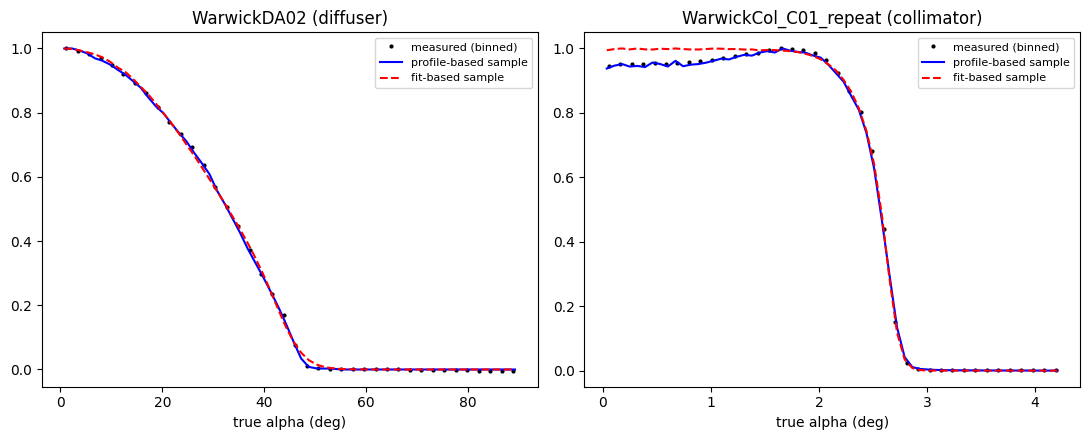

In [23]:
def build_1d_cdf_from_model(model_fn, params, alpha_max, jacobian_fn, n_fine=2000):
    """Analytic-model equivalent of build_2d_cdf's marginal step: integrate
    model_fn(alpha, *params) * jacobian_fn(alpha) over a fine alpha grid to get an
    invertible 1D CDF. jacobian_fn=sin here -- alpha is the true off-boresight polar
    angle, not the native grid's delta_theta (see markdown above)."""
    fine = np.linspace(0.0, alpha_max, n_fine)
    density = np.clip(model_fn(fine, *params), 0, None) * jacobian_fn(fine)
    cdf = np.concatenate([[0.0], np.cumsum(0.5 * (density[1:] + density[:-1]) * np.diff(fine))])
    return fine, cdf / cdf[-1]


def sample_from_fit(sample_id, n=2_000_000*10, seed=0):
    """Fit-backed sampler: alpha drawn from the fitted composite model (weighted by
    sin(alpha)), phi drawn uniformly around the boresight (the fit's own rotational-symmetry
    assumption). Same n/seed-in, (alpha, phi)-out contract as sample_common_profile."""
    fit = fit_common_profile(sample_id)
    fine_alpha, cdf = build_1d_cdf_from_model(
        composite, fit['params'], fit['alpha_max'], jacobian_fn=lambda a: np.sin(np.radians(a)))
    rng = np.random.default_rng(seed)
    alpha_s = np.interp(rng.uniform(size=n), cdf, fine_alpha)
    phi_s = rng.uniform(0.0, 360.0, size=n)
    return fit, alpha_s, phi_s


def compare_methods(sample_id, ax):
    """Compare the profile-backed and fit-backed samplers on the same true-alpha axis --
    both now go through to_boresight_frame (defined above) instead of duplicating that
    device-specific reduction locally.

    The recovery Jacobian still has to match *how the alpha was actually generated*, not
    just its physical meaning -- to_boresight_frame's collimator alpha comes from
    recenter_3d, a genuine rotation mixing real theta and real phi, and that one needs
    sin(alpha). Its diffuser alpha is literally the same |delta_theta| sample_common_
    profile's cosTheta sampler already weights by cos(delta_theta) (validated in
    validate_sampler) -- no recentering happened, so it still needs cos(alpha), regardless
    of also being "the true off-axis angle" in a physical sense. (An earlier version of
    this cell used sin(alpha) for both, on the mistaken assumption that representing a true
    off-boresight angle was enough to determine the Jacobian -- it produced exactly the
    spike-then-collapse artifact this distinction was already found to explain.)
    """
    fit, alpha_f, _ = sample_from_fit(sample_id)
    _, _, _, device_type, s1_p, s2_p = sample_common_profile(sample_id)
    alpha_p, _ = to_boresight_frame(device_type, s1_p, s2_p)

    bin_width = max(fit['alpha_max'] / 60, 0.05)
    bins = np.arange(0, fit['alpha_max'] + bin_width, bin_width)
    centers = 0.5 * (bins[1:] + bins[:-1])
    jac_p = np.sin(np.radians(centers)) if device_type == 'collimator' else np.cos(np.radians(centers))
    jac_f = np.sin(np.radians(centers))

    def hist_density(alpha_s, jac):
        counts, _ = np.histogram(alpha_s, bins=bins)
        dens = counts / np.maximum(jac, 1e-6)
        return dens / dens.max()

    ax.plot(fit['alpha'], fit['intensity'], 'k.', ms=4, label='measured (binned)')
    ax.plot(centers, hist_density(alpha_p, jac_p), 'b-', label='profile-based sample')
    ax.plot(centers, hist_density(alpha_f, jac_f), 'r--', label='fit-based sample')
    ax.set_title(f'{sample_id} ({device_type})'); ax.set_xlabel('true alpha (deg)'); ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
compare_methods('WarwickDA02', axes[0])
compare_methods('WarwickCol_C01_repeat', axes[1])
fig.tight_layout(); plt.show()

## A genuine 2D profile, not the phi-averaged 1D alpha curve

Every check so far (`validate_sampler`, `compare_methods`) collapsed onto `alpha` alone
(`grid.mean(axis=0)`), which is exactly the wrong thing to look at if the point is to confirm
real azimuthal structure survives -- averaging over phi is what would hide it.
`sample_common_profile` itself never averages phi away: rejection sampling draws `(cosTheta,
phi)` candidates over the full native extent and tests them against the full 2D density, so
nothing about the sampler collapses phi. Below: the native measured 2D grid next to a 2D
histogram of the sampler's own output, for both device types, at the same unfolded, signed
`delta_theta` / raw `phi` axes for both -- no phi-averaging anywhere in this comparison.

/tmp/ipykernel_598689/16187076.py:122: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  marginal = np.trapz(dense, fine_phi, axis=0)  # no jacobian -- u is already flat


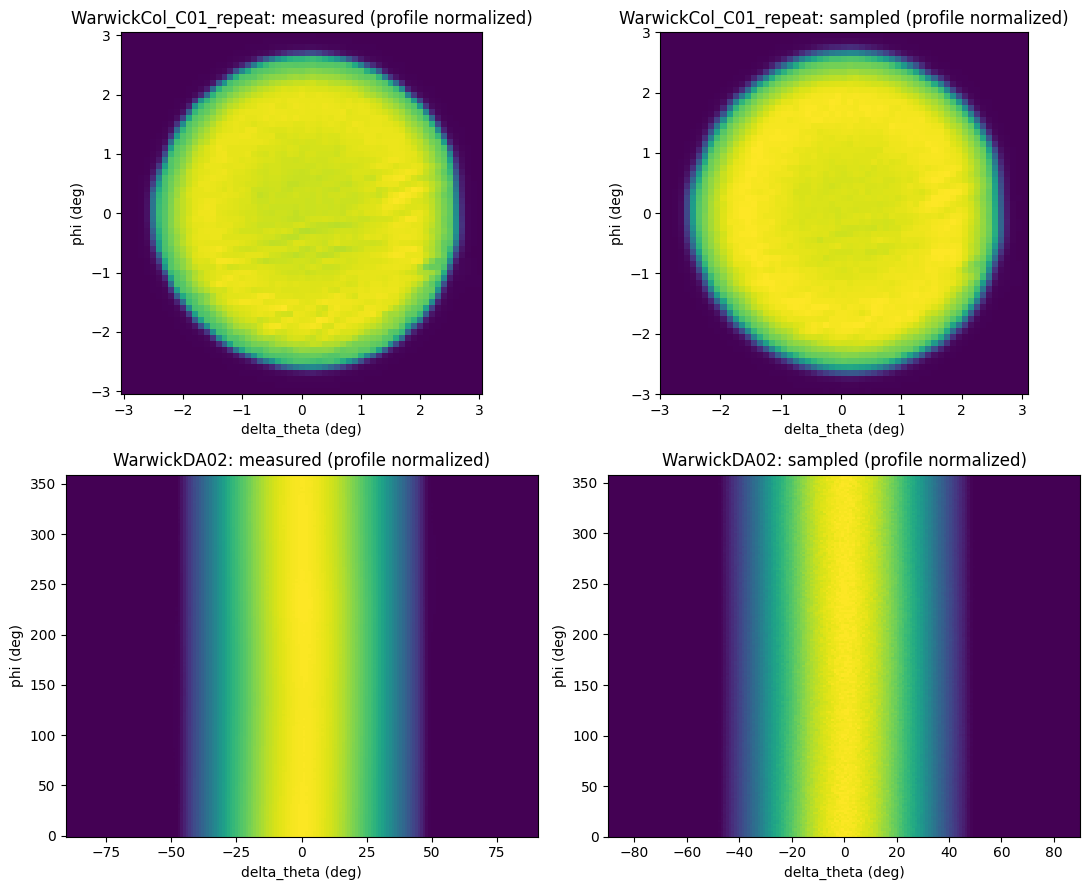

In [ ]:
def compare_2d(sample_id, axes):
    """Whole-profile normalization for each 2D profile.

    The sampled histogram is normalized by a robust reference (a high percentile), not
    its literal max -- with a finite sample split across tens of thousands of cells, the
    single highest bin is an extreme-value statistic that runs systematically above the
    true peak (more cells competing near the peak means a higher expected max, from
    Poisson noise alone). Dividing the whole panel by that one inflated bin dims the real
    peak and makes low-count tail bins look relatively brighter by comparison -- the same
    class of normalization fragility found earlier with the jacobian-divide version, just
    smaller in scale now that there's no jacobian amplifying it further. `native`'s own
    normalization stays a plain max since it's an exact, noiseless grid value, not sampled.
    """
    axis1_vals, axis2_vals, grid, device_type, s1, s2 = sample_common_profile(
        sample_id, n=2_000_000
    )

    bin1 = np.median(np.diff(axis1_vals))
    bin2 = np.median(np.diff(axis2_vals))

    edges1 = np.arange(axis1_vals.min(), axis1_vals.max() + bin1, bin1)
    edges2 = np.arange(axis2_vals.min(), axis2_vals.max() + bin2, bin2)

    sampled_counts, _, _ = np.histogram2d(
        s1, s2, bins=[edges1, edges2]
    )
    sampled_counts = sampled_counts.T

    def profile_normalize(a, robust=False):
        """Normalize by max, or (robust=True) by a high percentile of the positive
        entries, to avoid a single noisy bin dominating the scale."""
        if robust and np.any(a > 0):
            scale = np.percentile(a[a > 0], 99.5)
        else:
            scale = a.max()
        return np.divide(a, scale, out=np.zeros_like(a, dtype=float), where=scale > 0)

    # Normalize each complete 2D profile independently
    native = profile_normalize(grid)
    sampled = profile_normalize(sampled_counts, robust=True)

    axes[0].pcolormesh(
        edges_from_centers(axis1_vals),
        edges_from_centers(axis2_vals),
        native,
        cmap='viridis',
        vmin=0,
        vmax=1
    )
    axes[0].set_title(f'{sample_id}: measured (profile normalized)')

    axes[1].pcolormesh(
        edges1,
        edges2,
        sampled,
        cmap='viridis',
        vmin=0,
        vmax=1
    )
    axes[1].set_title(f'{sample_id}: sampled (profile normalized)')

    # both device types now use the same unfolded, signed delta_theta / raw phi convention
    for ax in axes:
        ax.set_xlabel('delta_theta (deg)')
        ax.set_ylabel('phi (deg)')
        ax.set_aspect(
            'equal' if device_type == 'collimator' else 'auto'
        )


fig, axes = plt.subplots(2, 2, figsize=(11, 9))

compare_2d('WarwickCol_C01_repeat', axes[0])
compare_2d('WarwickDA02', axes[1])

fig.tight_layout()
plt.show()